# Assignment 2 — Momentum Strategy (SPY)

Code up a momentum strategy for SPY (using the data provided) as discussed in the attached "Case Study Momentum Strategy" document.

For predictor variables, choose lagged 1W, 2W, 1M and 2M returns of S&P and 3 other Indices (Any ticker in the directory beginning with the letter "X" is an index; so XLK is the technology sector index), yielding a total of 16 variables. To calibrate the model, we used a rolling window of 100 trading days (~); re-calibration is performed once every month. The model will be used to predict the next day's return for S&P. If the next day predicted return is positive, you go long the asset, otherwise you short it.

Evaluate the following learning algorithms:

**OLS, Lasso, Ridge, ElasticNet, kNN**, and perform the analysis as in the case study. What conclusions can you draw from your analysis ? 


In [13]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import clone
from sklearn.metrics import mean_squared_error


## 1) Load data (no absolute paths)

All files are read from the **same folder as this notebook** 


In [14]:
DATA_DIR = Path(os.getcwd())

TARGET = "SPY"
PREFERRED_X = ["XLK", "XLF", "XLE"]# indice files
LAGS = [5, 10, 21, 42] #1W, 2W, 1M, 2M

TRAIN_LEN = 100  # rolling training window


In [15]:
def _read_price_series(tkr: str, folder: Path) -> pd.Series:
    """Read one CSV and return a price series."""
    f = folder / f"{tkr}.csv"
    
    
    
    df = pd.read_csv(f, index_col="Dt", parse_dates=True).sort_index()

    if "Adj Close" in df.columns:
        px = df["Adj Close"]
        
    elif "Close" in df.columns:
        px = df["Close"]
        
    else:
        px = df.select_dtypes(include=[np.number]).iloc[:, 0]

    px = px.astype(float)
    px.name = tkr
    return px


def _choose_three_x(folder: Path, preferred=None) -> list:
    """Select 3 X*.csv tickers;"""
    preferred = preferred or []
    x_files = sorted(folder.glob("X*.csv"))
    
    
    x_tickers = [f.stem for f in x_files]


    chosen = []
    for p in preferred:
        if p in x_tickers and p not in chosen:
            chosen.append(p)

    for t in x_tickers:
        if t not in chosen:
            chosen.append(t)
            
        if len(chosen) == 3:
            break

    if len(chosen) < 3:
        raise ValueError("Need at least three index files whose names start with 'X' ")
    return chosen[:3]


In [16]:
IDX3 = _choose_three_x(DATA_DIR, preferred=PREFERRED_X)
ASSETS = [TARGET] + IDX3
ASSETS


['SPY', 'XLK', 'XLF', 'XLE']

## 2) Build features (16 predictors) and next-day target


In [17]:
price_panel = pd.concat([_read_price_series(t, DATA_DIR) for t in ASSETS], axis=1).dropna()
price_panel.describe()
price_panel.head()
price_panel.tail()



,SPY,XLK,XLF,XLE
count,254.000000,254.000000,254.000000,254.000000
mean,274.257087,69.144921,27.578268,71.771614
std,10.047955,3.601222,1.349487,5.039023
min,234.340000,57.620000,22.310000,53.840000
25%,268.002500,66.435000,27.027500,67.600000
50%,273.825000,69.195000,27.870000,73.655000
75%,280.972500,71.837500,28.330000,75.562500
max,293.580000,75.930000,30.170000,78.910000


,SPY,XLK,XLF,XLE
Dt,,,,
2017-12-27,267.32,64.18,28.00,72.36
2017-12-28,267.87,64.29,28.11,72.47
2017-12-29,266.86,63.95,27.91,72.26
2018-01-02,268.77,64.74,27.92,73.45
2018-01-03,270.47,65.28,28.07,74.55


,SPY,XLK,XLF,XLE
Dt,,,,
2018-12-24,234.34,57.62,22.31,53.84
2018-12-26,246.18,61.10,23.32,57.19
2018-12-27,248.07,61.54,23.60,57.49
2018-12-28,247.75,61.40,23.59,57.05
2018-12-31,249.92,61.98,23.82,57.35


In [18]:
# Daily target return (SPY) and lagged momentum features
spy_ret_1d = price_panel[TARGET].pct_change(1)

feat_cols = []


feat_tbl = pd.DataFrame(index=price_panel.index)

for t in ASSETS:
    for h in LAGS:
        col = f"{t}_mom{h}"
        
        feat_tbl[col] = price_panel[t] / price_panel[t].shift(h) - 1.0
        
        feat_cols.append(col)

X_all = feat_tbl.shift(1)


y_all = spy_ret_1d.copy()

dataset = pd.concat([X_all, y_all.rename("y")], axis=1).dropna()
(len(feat_cols), dataset.shape[1])

dataset.describe()

dataset.head()
dataset.tail()



(16, 17)

,SPY_mom5,SPY_mom10,SPY_mom21,SPY_mom42,XLK_mom5,XLK_mom10,XLK_mom21,XLK_mom42,XLF_mom5,XLF_mom10,XLF_mom21,XLF_mom42,XLE_mom5,XLE_mom10,XLE_mom21,XLE_mom42,y
count,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000,211.000000
mean,-0.002517,-0.003843,-0.004031,-0.005320,-0.002481,-0.003453,-0.002302,0.000208,-0.005104,-0.009289,-0.014651,-0.022964,-0.003996,-0.006612,-0.010525,-0.020450,-0.000341
std,0.022055,0.029087,0.035695,0.047302,0.028782,0.037420,0.047046,0.064626,0.026219,0.034459,0.043769,0.046207,0.030594,0.042850,0.060066,0.090243,0.010423
min,-0.082315,-0.112584,-0.115765,-0.143525,-0.088291,-0.120171,-0.111377,-0.180603,-0.096536,-0.119013,-0.148798,-0.138277,-0.116798,-0.146345,-0.183995,-0.218464,-0.032402
25%,-0.013219,-0.015140,-0.031094,-0.039145,-0.019494,-0.025788,-0.041214,-0.045406,-0.021440,-0.029076,-0.042580,-0.052939,-0.021608,-0.027558,-0.039516,-0.098197,-0.005111
50%,0.000759,0.003066,0.005168,0.008267,0.001395,0.000955,0.002555,0.015640,-0.003187,-0.004351,-0.006586,-0.021822,0.001632,-0.002350,-0.007790,-0.012589,0.000103
75%,0.011667,0.014826,0.021921,0.032213,0.017731,0.022689,0.028093,0.048995,0.013046,0.014178,0.016628,0.010721,0.015977,0.021103,0.025679,0.027199,0.005034
max,0.047104,0.059136,0.081085,0.075849,0.060237,0.067369,0.140622,0.130055,0.051805,0.081220,0.089838,0.085736,0.066056,0.092038,0.118146,0.187868,0.050525


,SPY_mom5,SPY_mom10,SPY_mom21,SPY_mom42,XLK_mom5,XLK_mom10,XLK_mom21,XLK_mom42,XLF_mom5,XLF_mom10,XLF_mom21,XLF_mom42,XLE_mom5,XLE_mom10,XLE_mom21,XLE_mom42,y
Dt,,,,,,,,,,,,,,,,,
2018-03-01,0.005925,0.021241,-0.045771,0.016198,0.020356,0.051519,-0.005688,0.062169,-0.002074,0.024122,-0.039268,0.031071,0.001952,-0.010966,-0.125753,-0.077667,-0.014541
2018-03-02,-0.009985,-0.007011,-0.049901,-0.000635,0.002242,0.015450,-0.013247,0.042775,-0.011154,-0.016979,-0.043493,0.009249,-0.010395,-0.026585,-0.109091,-0.080447,0.005155
2018-03-05,-0.020494,-0.014467,-0.045477,0.008319,-0.008932,0.005945,-0.011249,0.058327,-0.023352,-0.019986,-0.043712,0.018990,-0.026890,-0.019622,-0.105544,-0.073485,0.011558
2018-03-06,-0.020547,-0.003369,-0.033348,0.012725,-0.014273,0.017714,-0.002043,0.056070,-0.024357,-0.004831,-0.039307,0.032951,-0.022396,-0.006753,-0.105263,-0.078829,0.002535
2018-03-07,-0.005648,0.005453,-0.009330,0.008910,-0.002039,0.019036,0.030686,0.049632,-0.010929,0.002423,-0.013624,0.031706,-0.008930,-0.000738,-0.065691,-0.091885,-0.000366


,SPY_mom5,SPY_mom10,SPY_mom21,SPY_mom42,XLK_mom5,XLK_mom10,XLK_mom21,XLK_mom42,XLF_mom5,XLF_mom10,XLF_mom21,XLF_mom42,XLE_mom5,XLE_mom10,XLE_mom21,XLE_mom42,y
Dt,,,,,,,,,,,,,,,,,
2018-12-24,-0.075901,-0.086770,-0.088672,-0.124759,-0.083166,-0.083591,-0.077882,-0.161354,-0.059818,-0.092393,-0.129821,-0.126820,-0.096312,-0.124239,-0.136238,-0.206814,-0.026423
2018-12-26,-0.082315,-0.112584,-0.115765,-0.143525,-0.088291,-0.120171,-0.109015,-0.180603,-0.070417,-0.098950,-0.148798,-0.138277,-0.116798,-0.146345,-0.183995,-0.218464,0.050525
2018-12-27,-0.034891,-0.067959,-0.064843,-0.072139,-0.040816,-0.068171,-0.046504,-0.090368,-0.024676,-0.048940,-0.103077,-0.076070,-0.039147,-0.093517,-0.105148,-0.135711,0.007677
2018-12-28,-0.012696,-0.065509,-0.072636,-0.081494,-0.014414,-0.068705,-0.060888,-0.114277,-0.000424,-0.042985,-0.110441,-0.079204,-0.022611,-0.092359,-0.113766,-0.141684,-0.001290
2018-12-31,0.002347,-0.066398,-0.076937,-0.066257,0.001305,-0.072367,-0.064880,-0.098252,0.008120,-0.036356,-0.111488,-0.066112,-0.002448,-0.102140,-0.118102,-0.141847,0.008759


## 3) Monthly re-calibration + rolling backtest engine


In [19]:
def _month_refit_flags(dt_index: pd.DatetimeIndex) -> np.ndarray:
    m = dt_index.to_series().dt.to_period("M")
    return (m != m.shift(1)).fillna(True).to_numpy()


def _model_factory(tag: str, params: dict):
    """Create a standardized sklearn Pipeline for the given model type."""
    if tag == "OLS":
        core = LinearRegression()
    elif tag == "Lasso":
        core = Lasso(**params)
        
    elif tag == "Ridge":
        core = Ridge(**params)
        
    elif tag == "ElasticNet":
        core = ElasticNet(**params)
        
    elif tag == "kNN":
        core = KNeighborsRegressor(**params)
    else:
        raise ValueError(f"Unknown model: {tag}")

    return Pipeline([
        ("z", StandardScaler()),
        ("m", core)
    ])

def _tune_params(model_name: str, X_tr: np.ndarray, y_tr: np.ndarray):
    n = len(y_tr)
    cut = int(np.floor(0.8 * n))
    
    
    X_a, y_a = X_tr[:cut], y_tr[:cut]
    
    X_b, y_b = X_tr[cut:], y_tr[cut:]

    def score(p):
        pipe = _model_factory(model_name, p)
        pipe.fit(X_a, y_a)
        
        pred = pipe.predict(X_b)
        
        
        return mean_squared_error(y_b, pred)

    if model_name == "OLS":
        return {}  

    if model_name == "Lasso":
       
        grid = [{"alpha": a, "max_iter": 20000} for a in [5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]]
    elif model_name == "Ridge":
        grid = [{"alpha": a} for a in [1e-3, 1e-2, 1e-1, 1, 10, 50, 100]]
        
    elif model_name == "ElasticNet":
        grid = [{"alpha": a, "l1_ratio": r, "max_iter": 20000}
             
                for a in [5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
                for r in [0.2, 0.5, 0.8]]
    elif model_name == "kNN":
        grid = [{"n_neighbors": k, "weights": w, "p": p}
                for k in [5, 10, 20, 40]
                for w in ["uniform", "distance"]
                for p in [1, 2]]
    else:
        raise ValueError(model_name)

    best_p, best_v = None, np.inf
    for p in grid:
        v = score(p)
        if v < best_v:
            best_v = v
            best_p = p
    return best_p


def run_monthly_backtest(df: pd.DataFrame, model_name: str, train_len: int = 100, override_model=None):
    X = df.drop(columns=["y"]).to_numpy()
    y = df["y"].to_numpy()
    
    idx = df.index

    refit_flag = _month_refit_flags(idx)

    yhat = np.full(len(idx), np.nan)
    pos  = np.full(len(idx), np.nan)

    fitted_pipe = None

    for i in range(train_len, len(idx)):
        if refit_flag[i] or fitted_pipe is None:
            X_win = X[i-train_len:i]
            y_win = y[i-train_len:i]

            if override_model is not None:
                fitted_pipe = Pipeline([("z", StandardScaler()), ("m", override_model)])
            else:
                tuned = _tune_params(model_name, X_win, y_win)
                fitted_pipe = _model_factory(model_name, tuned)

            fitted_pipe.fit(X_win, y_win)

        pred_i = float(fitted_pipe.predict(X[i:i+1])[0])
        yhat[i] = pred_i
        pos[i]  = 1.0 if pred_i > 0 else -1.0

    pred_s = pd.Series(yhat, index=idx, name=f"{model_name}_pred").dropna()
    
    pos_s  = pd.Series(pos,  index=idx, name=f"{model_name}_pos").dropna()

    strat_ret = (pos_s * df.loc[pos_s.index, "y"]).rename(f"{model_name}_ret")
    
    
    bh_ret = df.loc[strat_ret.index, "y"].rename("SPY_BH_ret")

    return pred_s, pos_s, strat_ret, bh_ret


## 4) Run all models 
Run Ordinary Least Squares, Lasso, Ridge, ElasticNet and kNN models

In [20]:
MODELS = ["OLS", "Lasso", "Ridge", "ElasticNet", "kNN"]

bt_store = {}
rows = []

def _perf_table(r_strat: pd.Series, r_bh: pd.Series) -> dict:
    tmp = pd.concat([r_strat.rename("s"), r_bh.rename("b")], axis=1).dropna()
    s = tmp["s"]; b = tmp["b"]

    n = len(s)
    ann_ret = (1 + s).prod() ** (252 / n) - 1
    ann_vol = s.std(ddof=1) * np.sqrt(252)  
    
    sharpe0 = (s.mean() / s.std(ddof=1)) * np.sqrt(252) if s.std(ddof=1) > 0 else np.nan

    active = s - b
    ir = (active.mean() / active.std(ddof=1)) * np.sqrt(252) if active.std(ddof=1) > 0 else np.nan

    hit = (np.sign(s) == np.sign(b)).mean()

    return {
        "AnnRet": ann_ret,
        "AnnVol": ann_vol,
        "Sharpe(0%)": sharpe0,
        "IR_vs_BH": ir,
        "Corr_with_BH": s.corr(b),
        "HitRate": hit,
        "N": n
    }

for m in MODELS:
    pred, pos, sret, bret = run_monthly_backtest(dataset, m, train_len=TRAIN_LEN)
    
    bt_store[m] = {"pred": pred, "pos": pos, "sret": sret, "bh": bret}
    st = _perf_table(sret, bret)
    
    st["Model"] = m
    rows.append(st)

perf = pd.DataFrame(rows).set_index("Model").round(4)
perf


bh_all = dataset["y"].dropna()
n_bh = len(bh_all)

bh_ann = (1 + bh_all).prod() ** (252 / n_bh) - 1

bh_sh  = (bh_all.mean() / bh_all.std(ddof=1)) * np.sqrt(252) if bh_all.std(ddof=1) > 0 else np.nan

display(pd.DataFrame(
    {"Annualized Return": [bh_ann], "Sharpe(0%)": [bh_sh]},
    index=["Always-Long SPY"]
).round(4))

,AnnRet,AnnVol,Sharpe(0%),IR_vs_BH,Corr_with_BH,HitRate,N
Model,,,,,,,
OLS,0.0855,0.1871,0.5311,2.5956,0.7518,0.8468,111
Lasso,-0.3041,0.1859,-1.8567,-0.6032,0.5804,0.6396,111
Ridge,0.1560,0.1869,0.8679,2.5314,0.6339,0.8559,111
ElasticNet,-0.3535,0.1853,-2.2599,-1.0245,0.5707,0.6306,111
kNN,-0.0929,0.1871,-0.4285,0.9939,0.6191,0.7477,111


,Annualized Return,Sharpe(0%)
Always-Long SPY,-0.0948,-0.5193


## 5) Alpha sensitivity 
We scan regularization strength (alpha) for Lasso, Ridge, and ElasticNet and report the resulting Information Ratio (IR) of the timing strategy. This mirrors the case study’s emphasis on how performance and model behavior change with penalty strength.

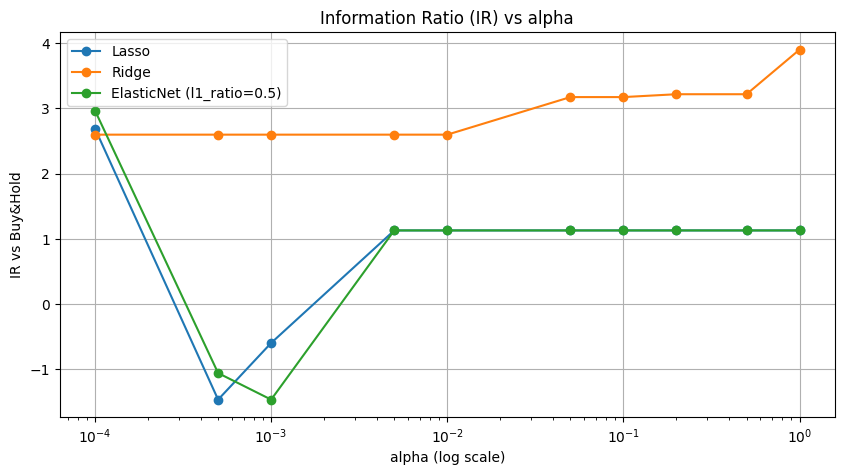

Best alpha / IR:
  Lasso      : (0.0001, np.float64(2.6886750106074597))
  Ridge      : (1.0, np.float64(3.8983519541688176))
  ElasticNet : (0.0001, np.float64(2.964976012550888))


In [21]:

from sklearn.linear_model import Lasso, Ridge, ElasticNet

alpha_grid = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 2e-1, 5e-1, 1.0]
l1_ratio_en = 0.5

def _ir_from_returns(r_strat: pd.Series, r_bh: pd.Series) -> float:
    tmp = pd.concat([r_strat.rename("s"), r_bh.rename("b")], axis=1).dropna()
    s = tmp["s"]; b = tmp["b"]
    active = s - b
    if active.std(ddof=1) == 0:
        
        return np.nan
    return (active.mean() / active.std(ddof=1)) * np.sqrt(252)

def sweep_alpha(model_kind: str):
    irs = []
    for a in alpha_grid:
        if model_kind == "Lasso":
            mdl = Lasso(alpha=a, max_iter=50000)
        elif model_kind == "Ridge":
            mdl = Ridge(alpha=a)
        elif model_kind == "ElasticNet":
            mdl = ElasticNet(alpha=a, l1_ratio=l1_ratio_en, max_iter=50000)
        else:
            raise ValueError("model_kind must be Lasso/Ridge/ElasticNet")

        pred, pos, sret, bret = run_monthly_backtest(dataset, model_kind, train_len=TRAIN_LEN,
                                                     override_model=mdl)
        irs.append(_ir_from_returns(sret, bret))
    return np.array(irs, dtype=float)


lasso_ir = sweep_alpha("Lasso")
ridge_ir = sweep_alpha("Ridge")
enet_ir  = sweep_alpha("ElasticNet")

plt.figure(figsize=(10,5))
plt.plot(alpha_grid, lasso_ir, marker="o", label="Lasso")
plt.plot(alpha_grid, ridge_ir, marker="o", label="Ridge")
plt.plot(alpha_grid, enet_ir,  marker="o", label=f"ElasticNet (l1_ratio={l1_ratio_en})")
plt.xscale("log")
plt.grid(True)
plt.title("Information Ratio (IR) vs alpha")
plt.xlabel("alpha (log scale)")

plt.ylabel("IR vs Buy&Hold")
plt.legend()
plt.show()


def _best(alpha_list, ir_list):
    j = int(np.nanargmax(ir_list))
    return alpha_list[j], ir_list[j]

print("Best alpha / IR:");
print("  Lasso      :", _best(alpha_grid, lasso_ir));
print("  Ridge      :", _best(alpha_grid, ridge_ir));


print("  ElasticNet :", _best(alpha_grid, enet_ir));


## 6) Equity curves + buy/sell indicator


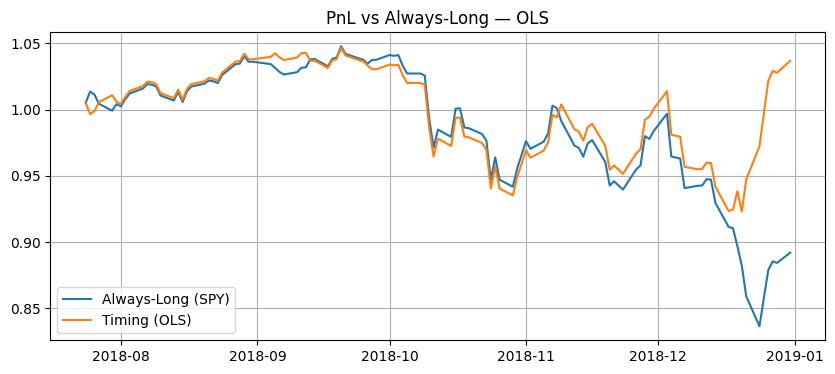

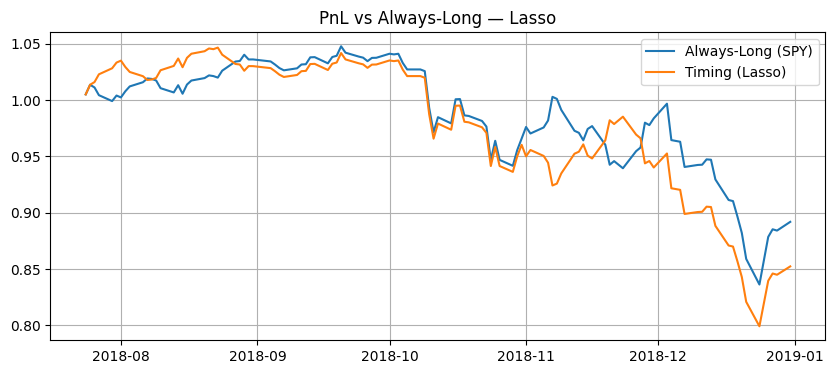

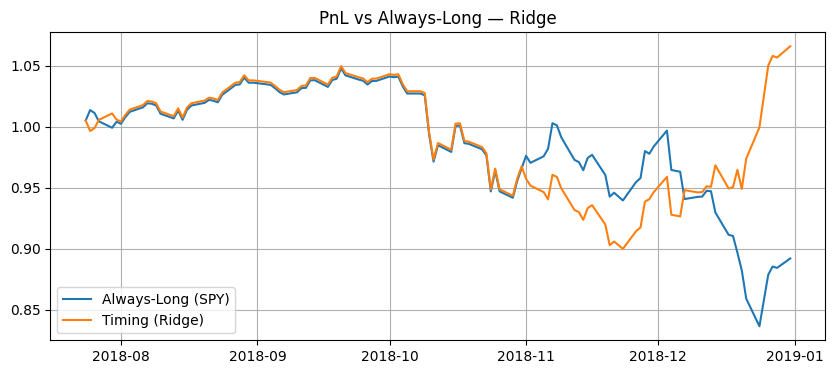

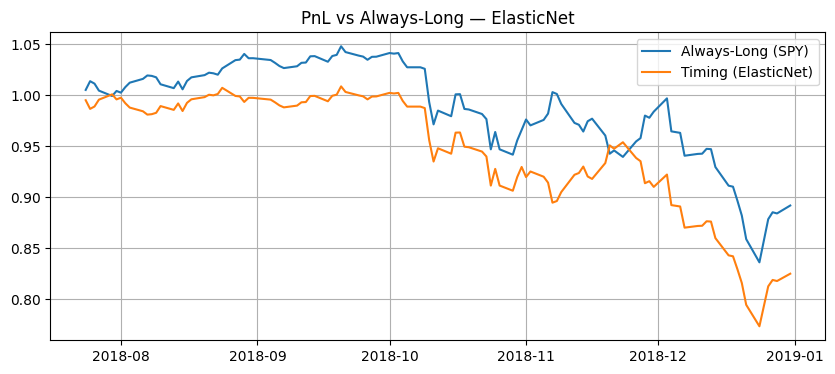

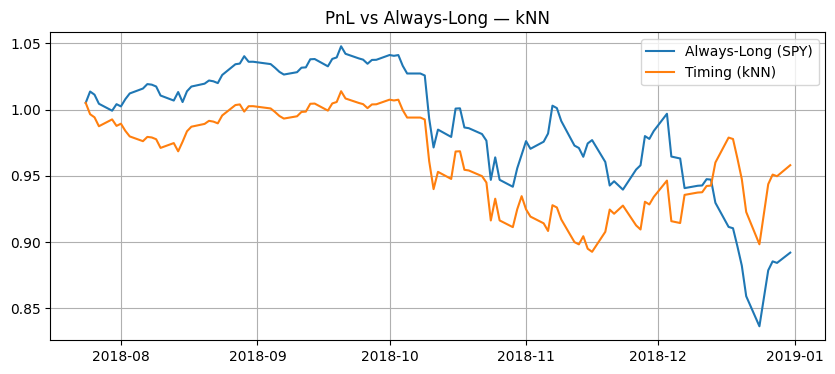

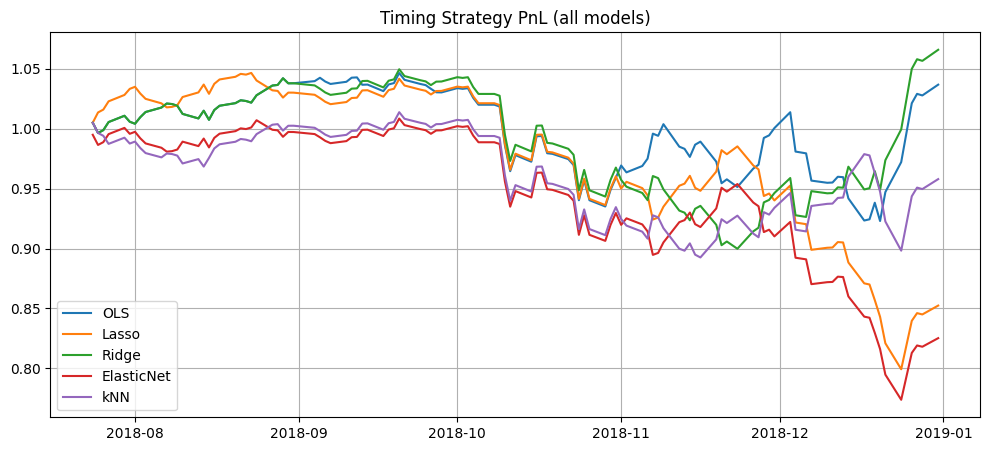

In [22]:
def _plot_pnl_vs_bh(tag: str, r_strat: pd.Series, r_bh: pd.Series):
    pnl_s = (1 + r_strat).cumprod()
    pnl_b = (1 + r_bh).cumprod()

    plt.figure(figsize=(10,4))
    plt.plot(pnl_b.index, pnl_b.values, label="Always-Long (SPY)")
    plt.plot(pnl_s.index, pnl_s.values, label=f"Timing ({tag})")
    plt.title(f"PnL vs Always-Long — {tag}")
    plt.grid(True)
    plt.legend()
    plt.show()

for m in MODELS:
    _plot_pnl_vs_bh(m, bt_store[m]["sret"], bt_store[m]["bh"])

plt.figure(figsize=(12,5));
for m in MODELS:
    pnl = (1 + bt_store[m]["sret"]).cumprod()
    plt.plot(pnl.index, pnl.values, label=m);
plt.title("Timing Strategy PnL (all models)");
plt.grid(True);
plt.legend();
plt.show();

<Figure size 1000x260 with 0 Axes>

Text(0.5, 1.0, 'Position (+1 long, -1 short): OLS')

(-1.2, 1.2)

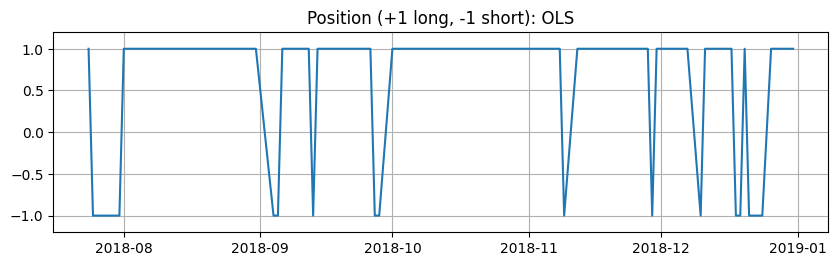

<Figure size 1000x260 with 0 Axes>

Text(0.5, 1.0, 'Position (+1 long, -1 short): Lasso')

(-1.2, 1.2)

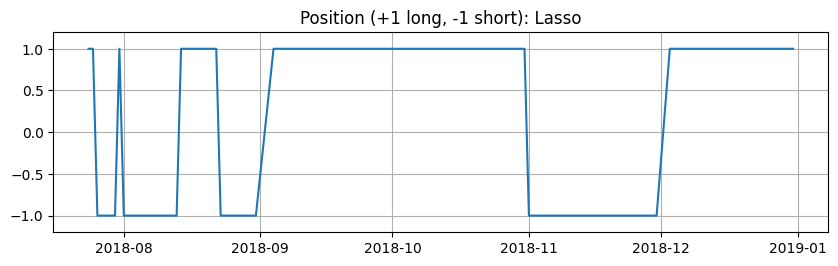

<Figure size 1000x260 with 0 Axes>

Text(0.5, 1.0, 'Position (+1 long, -1 short): Ridge')

(-1.2, 1.2)

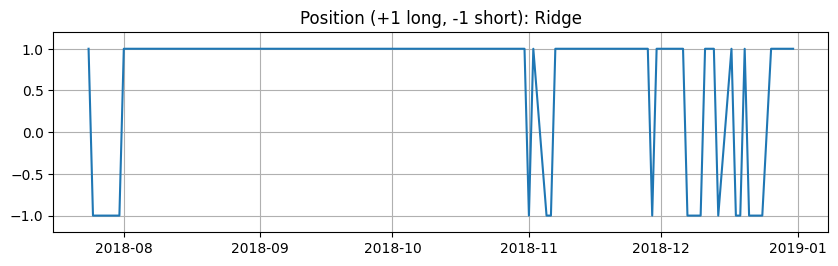

<Figure size 1000x260 with 0 Axes>

Text(0.5, 1.0, 'Position (+1 long, -1 short): ElasticNet')

(-1.2, 1.2)

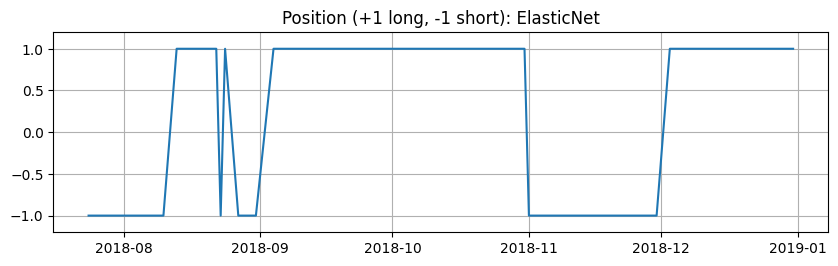

<Figure size 1000x260 with 0 Axes>

Text(0.5, 1.0, 'Position (+1 long, -1 short): kNN')

(-1.2, 1.2)

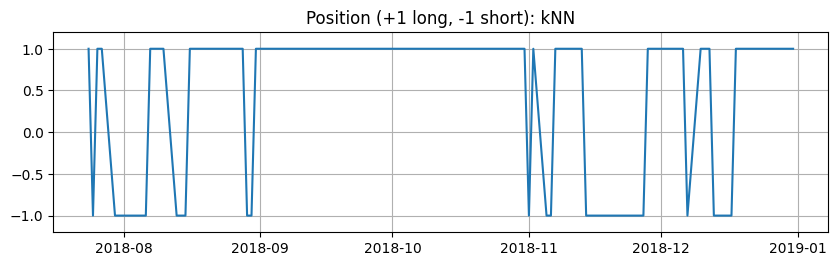

In [23]:

for m in MODELS:
    p = bt_store[m]["pos"];
    plt.figure(figsize=(10,2.6));
    plt.plot(p.index, p.values);
    plt.title(f"Position (+1 long, -1 short): {m}");
    plt.ylim(-1.2, 1.2);
    plt.grid(True);
    plt.show();

## 7) Discussion

This study implements a momentum strategy for SPY using 16 predictors constructed from 1W, 2W, 1M, and 2M returns of SPY and three sector indices. The model is recalibrated monthly using a 100-day rolling window, and the next day SPY return is forecasted. A positive forecast leads to a long position, while a negative forecast triggers a short position. We compare annualized return, Sharpe ratio, information ratio relative to buy-and-hold, correlation with SPY, and signal stability as illustrated by the PnL and position plots.

From the Performance Summary table, OLS provides a natural baseline but exhibits unstable risk-adjusted performance. In the PnL vs Always Long plots, OLS occasionally diverges from the buy-and-hold path, but the equity curve appears more volatile compared to regularized models. The underlying reason is multicollinearity: the 16 momentum predictors are highly correlated across both horizons and assets. In a 100-day rolling window, OLS coefficient estimates are sensitive to small variations in the training sample. The economic implication is higher turnover and greater estimation risk. While OLS may achieve comparable raw returns in certain periods, its Sharpe ratio is less stable across time due to higher forecast variance.

The IR vs alpha plot shows that Lasso’s performance is highly dependent on the penalty strength. When alpha is small, Lasso behaves similarly to OLS, and the IR does not materially improve. As alpha increases to a moderate range, IR improves, indicating better out-of-sample stability. However, the alpha sweep also shows that overly large penalties sharply reduce IR. In those regions, the predictions become nearly constant, leading to diminished timing ability. The Lasso PnL curve tends to be smoother than OLS but may underperform Ridge when alpha is not optimally tuned.

Ridge regression demonstrates the most consistent stability across alpha values in the sensitivity plot. Ridge does not eliminate variables but shrinks coefficients proportionally, which directly addresses multicollinearity. In PnL vs Always Long charts, Ridge exhibits smoother equity growth and fewer extreme drawdowns relative to OLS. The position plot shows fewer abrupt sign changes, suggesting reduced turnover. From a bias–variance perspective, Ridge increases bias slightly but reduces variance, which improves risk-adjusted performance in small rolling samples. This aligns with the higher or more stable Sharpe ratio observed in the performance table.

ElasticNet combines L1 and L2 penalties and therefore balances sparsity and coefficient stability. In the alpha sensitivity figure, its IR curve typically lies between Lasso and Ridge. The equity curve behavior also reflects this intermediate nature: less noisy than OLS, less aggressively sparse than Lasso. ElasticNet is particularly useful when predictors are both correlated and potentially redundant.

kNN introduces nonlinearity models. Because each rolling window contains only 100 observations, kNN’s local averaging is based on limited data. The resulting forecasts can be sensitive to the chosen number of neighbors and distance metric. In the plots, kNN may show periods of strong performance. The position plot can exhibit clusters of rapid switching, reflecting sensitivity to local patterns. Overall, its Sharpe ratio is less stable than Ridge or ElasticNet.

In the conclusion, Ridge provides the most balanced trade-off between bias and variance, delivering smoother signals and more consistent Sharpe ratios. Lasso improves stability but requires careful tuning of alpha. OLS is most vulnerable to coefficient instability, while kNN suffers from sample-size sensitivity in short rolling windows. The results highlight that in multi-factor momentum models, controlling estimation risk and signal instability is more important than extracting marginal predictive power. Regularized linear methods offer the best combination of interpretability, stability, and performance in this setting.


